# Hand Gesture Classification Project

This notebook show a complete workflow for classifying hand gestures using landmark data extracted with MediaPipe. We will build and compare two neural network architectures:
1.  **MLP (Multi-Layer Perceptron)**: A standard dense-only neural network.
2.  **1D-CNN (Convolutional Neural Network)**: A network designed to capture relationships between landmarks.

## Dataset Information
- **Features**: 63 features (21 landmarks × 3 coordinates: x, y, z).
- **Classes**: `open_palm`, `fist`, `index_finger`, `thumb_up`, `peace`, `ok`, `unrecognized`.

## 1. Setup the Environment 

In [5]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [6]:
DATASET_PATH = "dataset"
all_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")]

data_list = []

for file in all_files:
    file_path = os.path.join(DATASET_PATH, file)
    # Each file has a header (0, 1, 2... 63)
    df = pd.read_csv(file_path)
    data_list.append(df)

df = pd.concat(data_list, ignore_index=True)

# Data Cleaning: Strip whitespace and remove spurious "63" label
df.iloc[:, -1] = df.iloc[:, -1].astype(str).str.strip()
df = df[df.iloc[:, -1] != "63"]

print(f"Total samples loaded: {len(df)}")
print(f"Classes found: {df.iloc[:, -1].unique()}")
df.head()

Total samples loaded: 10397
Classes found: ['thumb_up' 'peace' 'open_palm' 'index_finger' 'unrecognized' 'ok' 'fist']


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.731883,0.724114,-1.617515e-07,0.711080,0.625828,0.000854,0.672356,0.532760,-0.008683,0.646340,...,0.594397,0.741789,-0.053940,0.616244,0.752387,-0.040072,0.636396,0.757009,-0.030343,thumb_up
1,0.731219,0.722570,-1.480493e-07,0.710017,0.624818,-0.000109,0.671120,0.533564,-0.009786,0.645615,...,0.594449,0.744926,-0.053683,0.616584,0.754845,-0.040585,0.637178,0.759049,-0.030961,thumb_up
2,0.730932,0.722369,-1.475366e-07,0.709002,0.624403,0.000256,0.668898,0.533471,-0.008973,0.643129,...,0.593147,0.745059,-0.050405,0.614646,0.754755,-0.037280,0.634921,0.757960,-0.027850,thumb_up
3,0.726251,0.711912,-1.422131e-07,0.705079,0.615604,0.003288,0.665384,0.527755,-0.004823,0.640511,...,0.590147,0.736593,-0.045648,0.610168,0.747066,-0.032121,0.629107,0.750577,-0.022953,thumb_up
4,0.721731,0.699657,-1.462421e-07,0.700153,0.604668,0.004473,0.661836,0.519104,-0.002559,0.636862,...,0.587185,0.726191,-0.040452,0.607161,0.737087,-0.027280,0.625828,0.739643,-0.018435,thumb_up


## 2. Data Loading

In [7]:
DATASET_PATH = 'dataset'
all_files = [f for f in os.listdir(DATASET_PATH) if f.endswith('.csv')]

data_list = []

for file in all_files:
    file_path = os.path.join(DATASET_PATH, file)
    df = pd.read_csv(file_path)
    data_list.append(df)

df = pd.concat(data_list, ignore_index=True)

# --- CLEANING STEP START ---
# 1. Strip whitespace from labels (merges 'open_palm ' and 'open_palm')
df.iloc[:, -1] = df.iloc[:, -1].astype(str).str.strip()

# 2. Remove rows with the spurious '63' label (only 1 sample exists)
df = df[df.iloc[:, -1] != '63']
# --- CLEANING STEP END ---

print(f"Total samples loaded: {len(df)}")
print(f"Classes found: {df.iloc[:, -1].unique()}")
df.head()


Total samples loaded: 10397
Classes found: ['thumb_up' 'peace' 'open_palm' 'index_finger' 'unrecognized' 'ok' 'fist']


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.731883,0.724114,-1.617515e-07,0.711080,0.625828,0.000854,0.672356,0.532760,-0.008683,0.646340,...,0.594397,0.741789,-0.053940,0.616244,0.752387,-0.040072,0.636396,0.757009,-0.030343,thumb_up
1,0.731219,0.722570,-1.480493e-07,0.710017,0.624818,-0.000109,0.671120,0.533564,-0.009786,0.645615,...,0.594449,0.744926,-0.053683,0.616584,0.754845,-0.040585,0.637178,0.759049,-0.030961,thumb_up
2,0.730932,0.722369,-1.475366e-07,0.709002,0.624403,0.000256,0.668898,0.533471,-0.008973,0.643129,...,0.593147,0.745059,-0.050405,0.614646,0.754755,-0.037280,0.634921,0.757960,-0.027850,thumb_up
3,0.726251,0.711912,-1.422131e-07,0.705079,0.615604,0.003288,0.665384,0.527755,-0.004823,0.640511,...,0.590147,0.736593,-0.045648,0.610168,0.747066,-0.032121,0.629107,0.750577,-0.022953,thumb_up
4,0.721731,0.699657,-1.462421e-07,0.700153,0.604668,0.004473,0.661836,0.519104,-0.002559,0.636862,...,0.587185,0.726191,-0.040452,0.607161,0.737087,-0.027280,0.625828,0.739643,-0.018435,thumb_up


## 3. Data Preprocessing

In [8]:
# Separate features (X) and labels (y)
# Columns 0-62 are features, column 63 is the label
X = df.iloc[:, :63].values
y = df.iloc[:, 63].values

# Normalize features to [0, 1] range
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# One-hot encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_one_hot = tf.keras.utils.to_categorical(y_encoded)

CLASS_NAMES = label_encoder.classes_
NUM_CLASSES = len(CLASS_NAMES)

# Split into Train (70%), Val (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X_normalized, y_one_hot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (7277, 63)
Validation set shape: (1560, 63)
Test set shape: (1560, 63)


## 4. Model 1: MLP

In [9]:
mlp_model = models.Sequential([
    layers.Input(shape=(63,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,759 (73.28 KB)

 Trainable params: 18,759 (73.28 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model 2: CNN

In [10]:
# CNN requires input shape (features, channels)
X_train_cnn = X_train.reshape(X_train.shape[0], 63, 1)
X_val_cnn = X_val.reshape(X_val.shape[0], 63, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], 63, 1)

cnn_model = models.Sequential([
    layers.Input(shape=(63, 1)),
    layers.Conv1D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 61, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       114,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,167 (547.53 KB)

 Trainable params: 140,167 (547.53 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training

In [11]:
EPOCHS = 30
BATCH_SIZE = 32

print("Training MLP Model...")
mlp_history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)



Training MLP Model...
Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4012 - loss: 1.5629 - val_accuracy: 0.9026 - val_loss: 0.4469
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - accuracy: 0.9011 - loss: 0.3860 - val_accuracy: 0.9474 - val_loss: 0.2140
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - accuracy: 0.9473 - loss: 0.1897 - val_accuracy: 0.9769 - val_loss: 0.1050
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.9710 - loss: 0.1188 - val_accuracy: 0.9865 - val_loss: 0.0605
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9834 - loss: 0.0712 - val_accuracy: 0.9885 - val_loss: 0.0476
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9855 - loss: 0.0637 - val_accuracy: 0.9929 - val_loss: 0.0370
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9901 - loss: 0.0461 - val_accuracy: 0.9846 - val_loss: 0.0486
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9909 - los

In [12]:
EPOCHS = 30
BATCH_SIZE = 32

print("\nTraining CNN Model...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Training CNN Model...
Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4743 - loss: 1.3971 - val_accuracy: 0.9269 - val_loss: 0.2357
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9472 - loss: 0.1771 - val_accuracy: 0.9865 - val_loss: 0.0763
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9807 - loss: 0.0866 - val_accuracy: 0.9904 - val_loss: 0.0458
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9836 - loss: 0.0637 - val_accuracy: 0.9942 - val_loss: 0.0349
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9897 - loss: 0.0440 - val_accuracy: 0.9897 - val_loss: 0.0428
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9891 - loss: 0.0424 - val_accuracy: 0.9936 - val_loss: 0.0290
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9942 - loss: 0.0255 - val_accuracy: 0.9942 - val_loss: 0.0177
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9929 - loss: 0.

## 7. Evaluation

### 7.1. Training History Plots

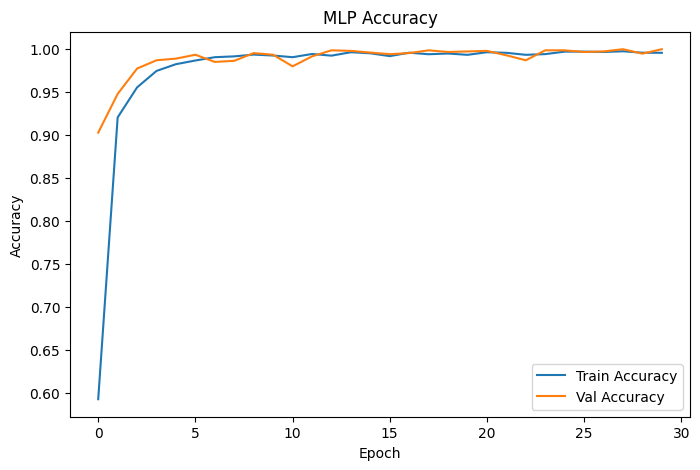

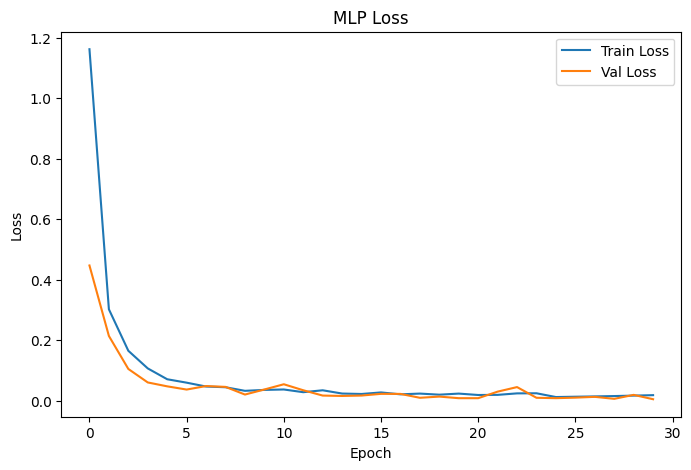

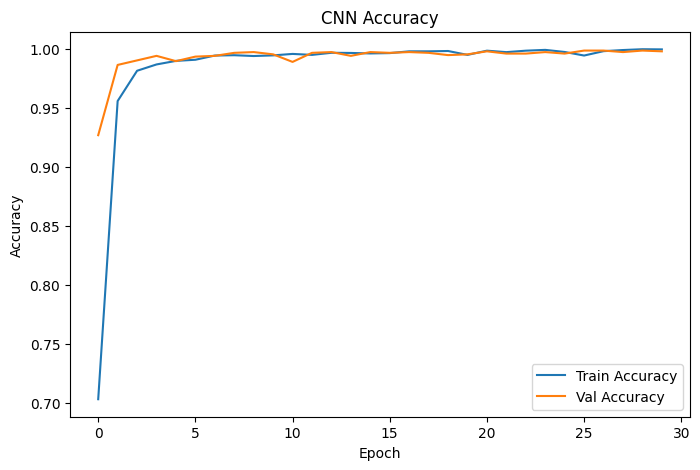

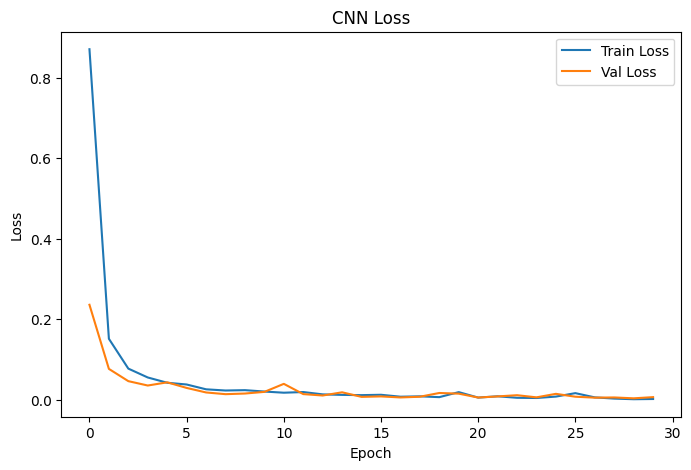

In [13]:
def plot_history(history, model_name):
    # Accuracy Plot
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

    # Loss Plot
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

plot_history(mlp_history, "MLP")
plot_history(cnn_history, "CNN")

### 7.2. Confusion Matrix 

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step

--- MLP Classification Report ---
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00       211
index_finger       0.99      1.00      0.99       184
          ok       1.00      0.99      0.99       185
   open_palm       0.99      1.00      1.00       176
       peace       1.00      0.99      1.00       218
    thumb_up       1.00      1.00      1.00       200
unrecognized       1.00      1.00      1.00       386

    accuracy                           1.00      1560
   macro avg       1.00      1.00      1.00      1560
weighted avg       1.00      1.00      1.00      1560



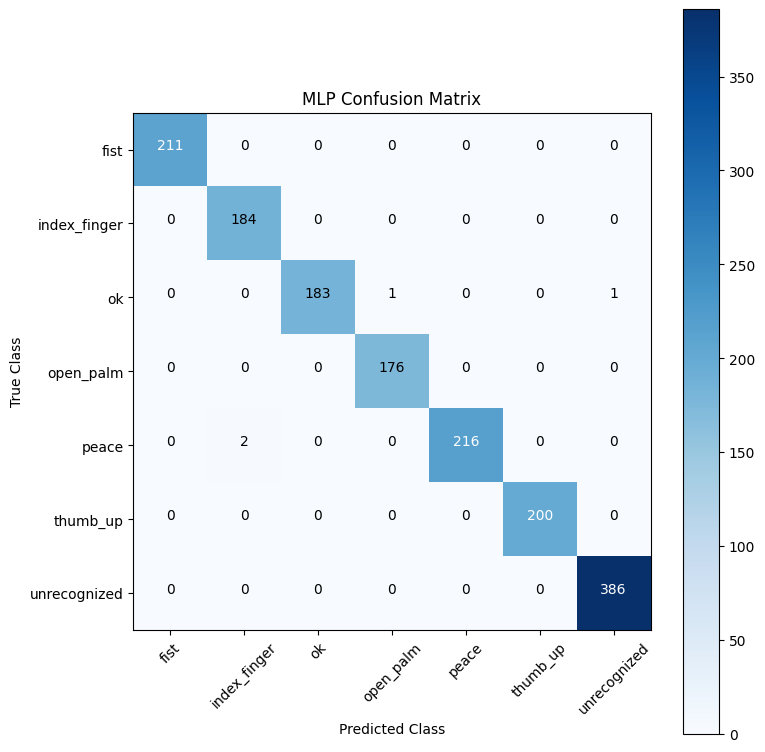

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- CNN Classification Report ---
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00       211
index_finger       0.99      1.00      1.00       184
          ok       1.00      0.99      1.00       185
   open_palm       1.00      1.00      1.00       176
       peace       1.00      1.00      1.00       218
    thumb_up       1.00      1.00      1.00       200
unrecognized       1.00      1.00      1.00       386

    accuracy                           1.00      1560
   macro avg       1.00      1.00      1.00      1560
weighted avg       1.00      1.00      1.00      1560



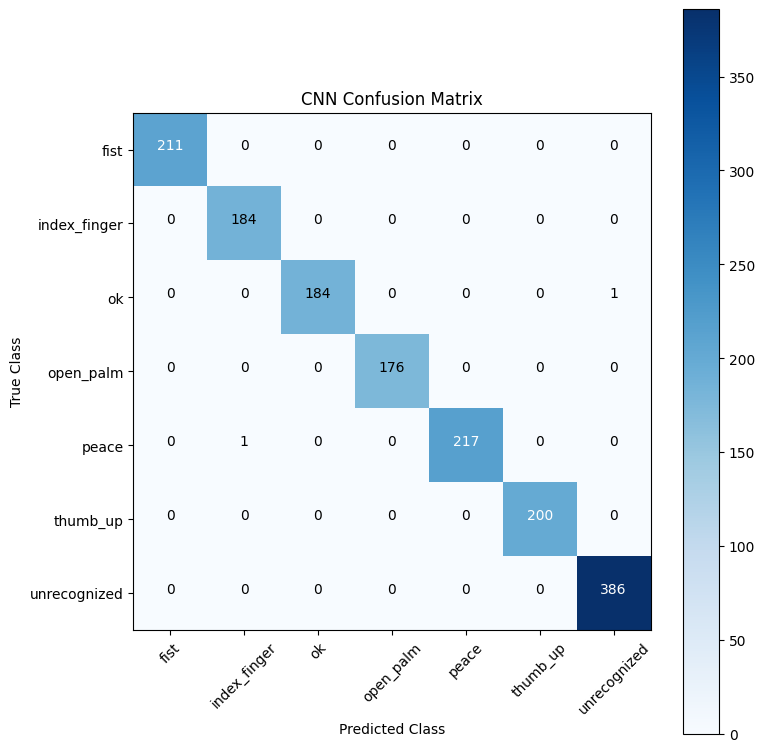

In [14]:
def evaluate_model(model, X_test_data, y_test_labels, model_name):
    y_pred = model.predict(X_test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test_labels, axis=1)

    # Classification Report
    print(f"\n--- {model_name} Classification Report ---")
    # We specify labels and target_names explicitly to match the current test set
    unique_labels = np.unique(y_true)
    current_target_names = [CLASS_NAMES[i] for i in unique_labels]
    
    print(classification_report(y_true, y_pred_classes, labels=unique_labels, target_names=current_target_names))

    # Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    
    tick_marks = np.arange(len(unique_labels))
    plt.xticks(tick_marks, current_target_names, rotation=45)
    plt.yticks(tick_marks, current_target_names)

    # Text annotations in matrix
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.show()
    
    return model.evaluate(X_test_data, y_test_labels, verbose=0)[1]

# Re-run evaluation
mlp_acc = evaluate_model(mlp_model, X_test, y_test, "MLP")
cnn_acc = evaluate_model(cnn_model, X_test_cnn, y_test, "CNN")


### 7.3. Comparing the 2 models results in 1 plot

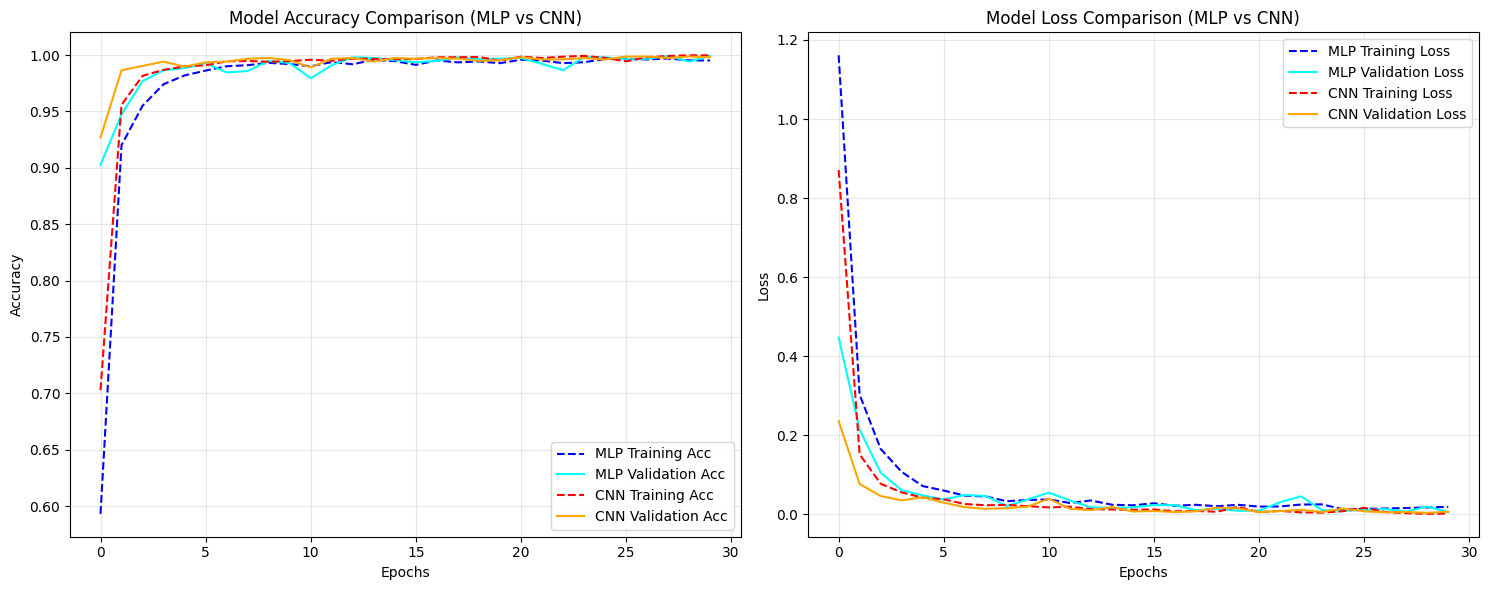

Final MLP Test Accuracy: 99.74%
Final CNN Test Accuracy: 99.87%
Difference: 0.13%


In [15]:
import matplotlib.pyplot as plt

# Set up the figure for side-by-side comparison
plt.figure(figsize=(15, 6))

# --- Plot 1: Accuracy Comparison ---
plt.subplot(1, 2, 1)
# MLP Accuracy (Blue/Cyan)
plt.plot(mlp_history.history['accuracy'], label='MLP Training Acc', color='blue', linestyle='--')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Validation Acc', color='cyan')
# CNN Accuracy (Red/Orange)
plt.plot(cnn_history.history['accuracy'], label='CNN Training Acc', color='red', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Acc', color='orange')

plt.title('Model Accuracy Comparison (MLP vs CNN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# --- Plot 2: Loss Comparison ---
plt.subplot(1, 2, 2)
# MLP Loss (Blue/Cyan)
plt.plot(mlp_history.history['loss'], label='MLP Training Loss', color='blue', linestyle='--')
plt.plot(mlp_history.history['val_loss'], label='MLP Validation Loss', color='cyan')
# CNN Loss (Red/Orange)
plt.plot(cnn_history.history['loss'], label='CNN Training Loss', color='red', linestyle='--')
plt.plot(cnn_history.history['val_loss'], label='CNN Validation Loss', color='orange')

plt.title('Model Loss Comparison (MLP vs CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Print Final Metrics comparison ---
print(f"Final MLP Test Accuracy: {mlp_acc*100:.2f}%")
print(f"Final CNN Test Accuracy: {cnn_acc*100:.2f}%")
print(f"Difference: {abs(cnn_acc - mlp_acc)*100:.2f}%")


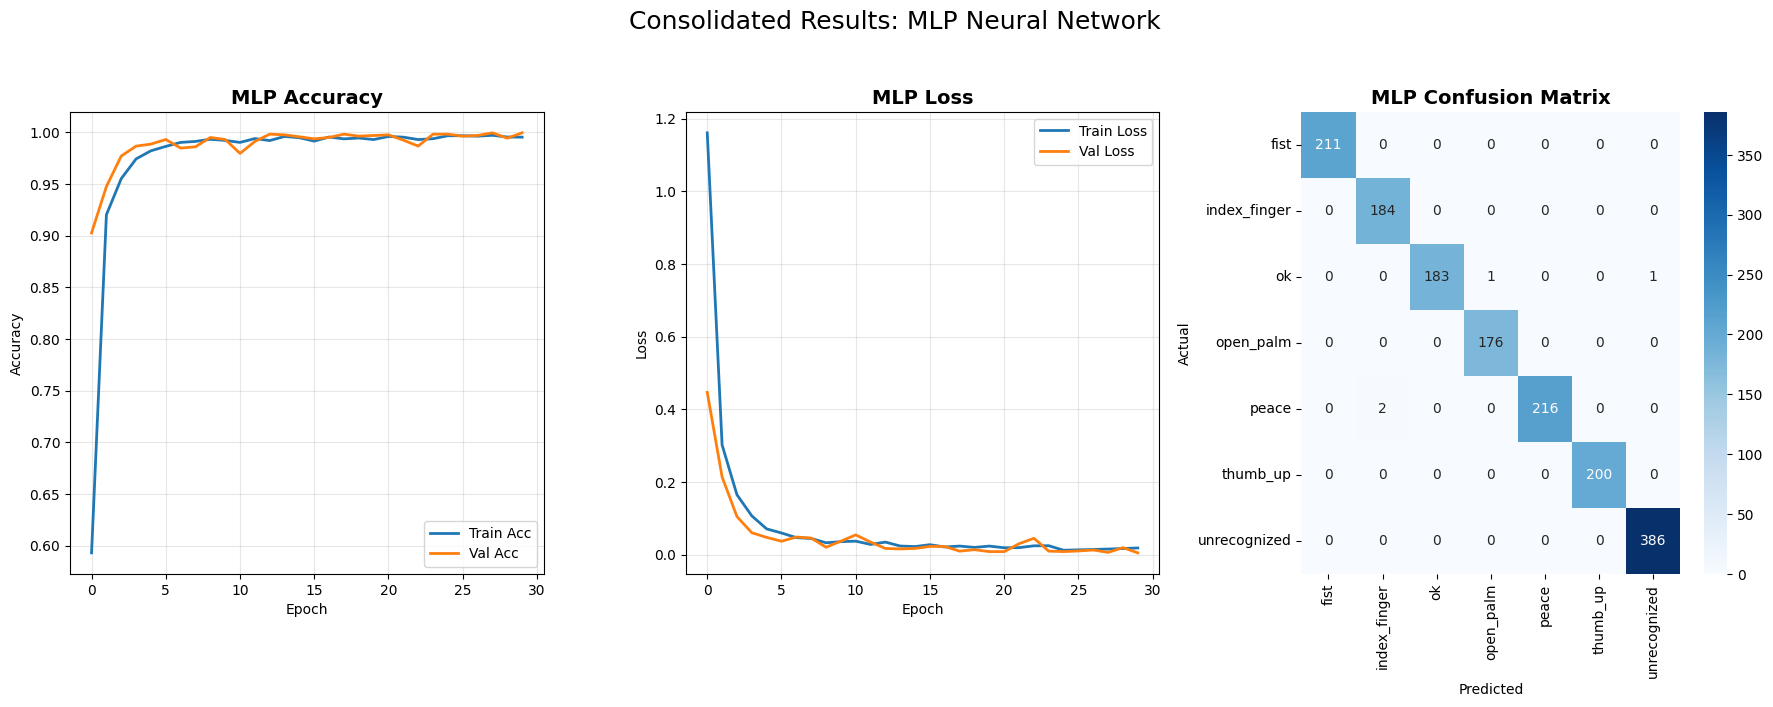

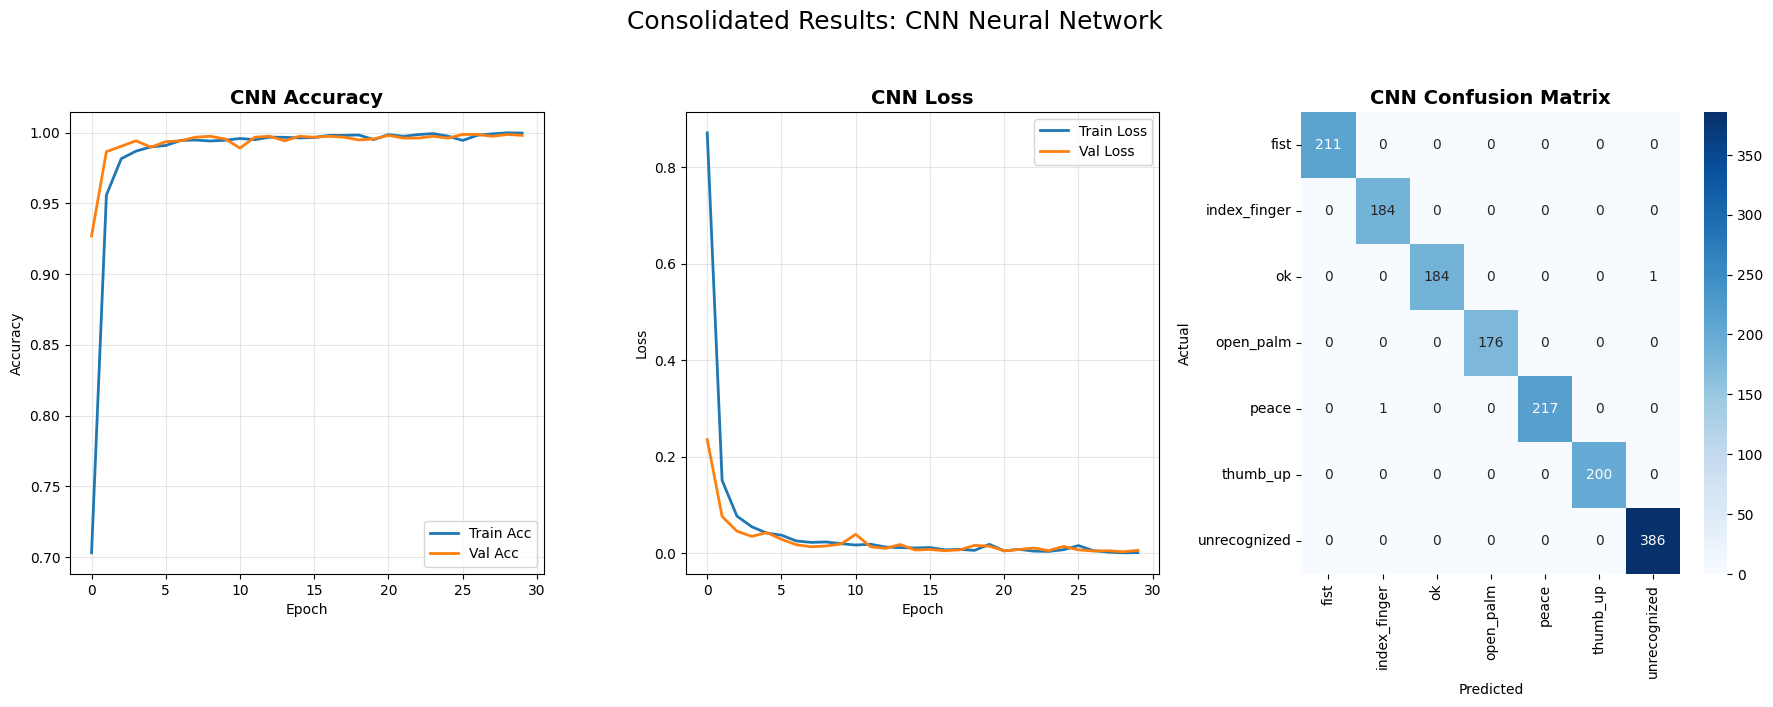


Metric               | MLP        | CNN       
---------------------------------------------
Train Accuracy       | 0.9952     | 0.9997
Val Accuracy         | 0.9994     | 0.9981
Test Accuracy        | 0.9974     | 0.9987


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Check if models are defined in the environment
if 'mlp_model' not in globals() or 'cnn_model' not in globals():
    print("❌ ERROR: Models not found. Please run the MLP and CNN training cells first!")
else:
    def plot_combined_performance(model, history, X_test_data, y_test_labels, model_name):
        # Prepare predictions
        y_pred = model.predict(X_test_data, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        y_true = np.argmax(y_test_labels, axis=1)
        
        # Create a single figure with 3 subplots
        fig, ax = plt.subplots(1, 3, figsize=(22, 6))
        plt.subplots_adjust(wspace=0.3)
        
        # 1. Accuracy Plot
        ax[0].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
        ax[0].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
        ax[0].set_title(f'{model_name} Accuracy', fontsize=14, fontweight='bold')
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Accuracy')
        ax[0].legend()
        ax[0].grid(True, alpha=0.3)
        
        # 2. Loss Plot
        ax[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
        ax[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
        ax[1].set_title(f'{model_name} Loss', fontsize=14, fontweight='bold')
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Loss')
        ax[1].legend()
        ax[1].grid(True, alpha=0.3)
        
        # 3. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred_classes)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2], 
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        ax[2].set_title(f'{model_name} Confusion Matrix', fontsize=14, fontweight='bold')
        ax[2].set_xlabel('Predicted')
        ax[2].set_ylabel('Actual')
        
        plt.suptitle(f"Consolidated Results: {model_name} Neural Network", fontsize=18, y=1.05)
        plt.show()

        # Evaluate and return Test Accuracy
        _, test_acc = model.evaluate(X_test_data, y_test_labels, verbose=0)
        return test_acc

    # Generate the plots
    mlp_test_acc = plot_combined_performance(mlp_model, mlp_history, X_test, y_test, "MLP")
    cnn_test_acc = plot_combined_performance(cnn_model, cnn_history, X_test_cnn, y_test, "CNN")

    # Final Stats Summary
    print("\n" + "="*45)
    print(f"{'Metric':<20} | {'MLP':<10} | {'CNN':<10}")
    print("-" * 45)
    print(f"{'Train Accuracy':<20} | {mlp_history.history['accuracy'][-1]:.4f}     | {cnn_history.history['accuracy'][-1]:.4f}")
    print(f"{'Val Accuracy':<20} | {mlp_history.history['val_accuracy'][-1]:.4f}     | {cnn_history.history['val_accuracy'][-1]:.4f}")
    print(f"{'Test Accuracy':<20} | {mlp_test_acc:.4f}     | {cnn_test_acc:.4f}")
    print("="*45)


In [20]:
# --- CNN Model Metrics ---
print("📊 [CNN] Performance Metrics")
print("-" * 30)

# Extract from history
cnn_train_acc = cnn_history.history['accuracy'][-1]
cnn_val_acc = cnn_history.history['val_accuracy'][-1]

# Evaluate on test set (note: CNN uses X_test_cnn)
_, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Training Accuracy:   {cnn_train_acc:.4f} ({cnn_train_acc*100:.2f}%)")
print(f"Validation Accuracy: {cnn_val_acc:.4f} ({cnn_val_acc*100:.2f}%)")
print(f"Test Accuracy:       {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")


📊 [CNN] Performance Metrics
------------------------------
Training Accuracy:   0.9997 (99.97%)
Validation Accuracy: 0.9981 (99.81%)
Test Accuracy:       0.9987 (99.87%)


In [19]:
# --- MLP Model Metrics ---
print("📊 [MLP] Performance Metrics")
print("-" * 30)

# Extract from history
mlp_train_acc = mlp_history.history['accuracy'][-1]
mlp_val_acc = mlp_history.history['val_accuracy'][-1]

# Evaluate on test set
_, mlp_test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy:   {mlp_train_acc:.4f} ({mlp_train_acc*100:.2f}%)")
print(f"Validation Accuracy: {mlp_val_acc:.4f} ({mlp_val_acc*100:.2f}%)")
print(f"Test Accuracy:       {mlp_test_acc:.4f} ({mlp_test_acc*100:.2f}%)")


📊 [MLP] Performance Metrics
------------------------------
Training Accuracy:   0.9952 (99.52%)
Validation Accuracy: 0.9994 (99.94%)
Test Accuracy:       0.9974 (99.74%)


## 8. Comparison of Accuracy


In [17]:
print(f"Final MLP Test Accuracy: {mlp_acc*100:.2f}%")
print(f"Final CNN Test Accuracy: {cnn_acc*100:.2f}%")

Final MLP Test Accuracy: 99.74%
Final CNN Test Accuracy: 99.87%


## 9. Save the 2 models

In [18]:
# import pickle
# # Save the models into their specific subfolders
# mlp_model.save('classification models/MLP model/mlp_model.h5')
# cnn_model.save('classification models/CNN model/cnn_model.h5')
# # Save the shared artifacts into the main classification models folder
# with open('classification models/labels.pkl', 'wb') as f:
#     pickle.dump(label_encoder, f)
# with open('classification models/scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)
# print("Export complete into the 'classification models' folder structure.")
